# Implementing k means

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/home/anish/anaconda3/lib/python3.7/site-packages/sklearn/utils/deprecation.py:144: FutureWarning: The sklearn.datasets.samples_generator module is  deprecated in version 0.22 and will be removed in version 0.24. The corresponding classes / functions should instead be imported from sklearn.datasets. Anything that cannot be imported from sklearn.datasets is now part of the private API.
  warnings.warn(message, FutureWarning)


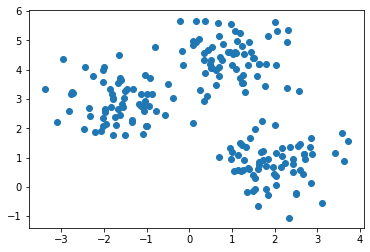

In [2]:
from sklearn.datasets.samples_generator import make_blobs
X, y_true = make_blobs(n_samples=200, centers=3,
                       cluster_std=0.70, random_state=0)
plt.scatter(X[:, 0], X[:, 1])

In [3]:
X.shape

(200, 2)

## Implementation Algorithm

- Choose k (num of clusters)
- Choose k centers
- Repeat until convergence:
    - Find distance of each point to each center
    - Assign point to closest center
    - Find new centers by taking mean of cluster points
    
* Convergence = centers don't change

# Choosing k(num of clusters)

In [4]:
k = 3

# Choosing k centers

In [5]:
np.random.seed(1)
# Choosing indices of three numbers from 200 numbers as our dataset has 200 datapoints.
center_indices = np.random.choice(200,size = 3)
#center_indices
# Returning centers corresponding to above indices.
centers = X[center_indices]
centers

array([[ 2.25121474,  0.82895839],
       [-1.6220688 ,  3.71370622],
       [ 0.67166259,  5.59827194]])

# Loop part:

In [6]:
from sklearn.metrics import pairwise_distances_argmin_min

In [7]:
cluster_assignments = []

SSE:  318.2640909316256


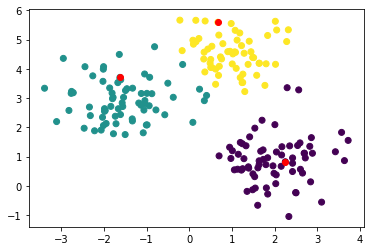

SSE:  186.47681538002763


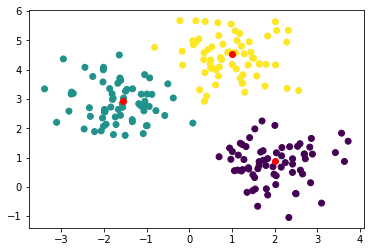

SSE:  184.237544165629


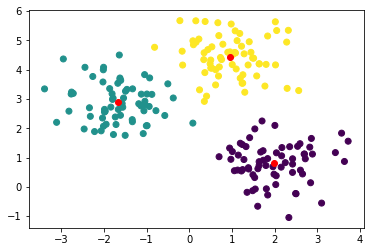

In [8]:
while True:
    #distances = pairwise_distances(X,centers, metric = 'euclidean')
    cluster_assignments, distances = pairwise_distances_argmin_min(X, centers,metric = 'euclidean')
    #print(distances.shape)
    print('SSE: ', np.sum(np.square(distances)))
    
    plt.scatter(X[:,0], X[:,1],c = cluster_assignments)
    plt.scatter(centers[:,0], centers[:,1],c = 'r')
    plt.show()
    # Find new center by taking mean of cluster points
    new_centers = []
    for i in range(k):
        cluster_points_index = cluster_assignments == i
        #print('Cluster',i)
        cluster_points = X[cluster_points_index]
        new_center = cluster_points.mean(axis = 0)
        new_centers.append(new_center)
    new_centers = np.array(new_centers)
    # new_centers = np.array([np.mean(X[cluster_assignments == i],axis = 0) for i in range(k)])
    
    if np.all(new_centers == centers):
        break
    
    centers = new_centers

In [9]:
print(centers)
print(cluster_assignments)

[[ 1.99127366  0.80487522]
 [-1.6656056   2.88982984]
 [ 0.9615202   4.43376825]]
[1 2 2 1 2 1 0 0 2 1 2 1 2 2 2 1 0 0 2 1 1 0 2 2 1 2 0 1 1 1 2 2 1 2 0 0 2
 0 0 1 0 1 1 1 2 2 2 1 2 2 2 0 1 1 1 1 0 0 2 2 1 1 2 0 0 1 0 0 1 0 0 2 2 1
 2 1 0 0 0 1 1 2 2 0 0 2 2 1 2 0 1 1 0 2 0 2 2 1 1 0 0 2 1 2 1 2 0 2 2 0 2
 1 0 1 2 2 2 0 1 1 0 0 1 2 0 2 1 0 1 2 1 0 0 0 2 0 0 2 0 1 1 1 2 0 0 2 1 1
 0 2 0 1 1 1 2 0 0 0 2 2 1 1 1 1 2 2 0 1 0 0 2 0 2 0 1 1 2 1 2 0 2 1 0 0 0
 2 1 0 2 2 1 1 0 0 0 0 1 0 2 0]


# sciktlearn

In [10]:
from sklearn.cluster import KMeans

In [11]:
kmeans = KMeans(n_clusters=3, random_state=1)
kmeans.fit(X)
print(kmeans.labels_)
print(kmeans.cluster_centers_)
print(kmeans.inertia_)

[1 2 2 1 2 1 0 0 2 1 2 1 2 2 2 1 0 0 2 1 1 0 2 2 1 2 0 1 1 1 2 2 1 2 0 0 2
 0 0 1 0 1 1 1 2 2 2 1 2 2 2 0 1 1 1 1 0 0 2 2 1 1 2 0 0 1 0 0 1 0 0 2 2 1
 2 1 0 0 0 1 1 2 2 0 0 2 2 1 2 0 1 1 0 2 0 2 2 1 1 0 0 2 1 2 1 2 0 2 2 0 2
 1 0 1 2 2 2 0 1 1 0 0 1 2 0 2 1 0 1 2 1 0 0 0 2 0 0 2 0 1 1 1 2 0 0 2 1 1
 0 2 0 1 1 1 2 0 0 0 2 2 1 1 1 1 2 2 0 1 0 0 2 0 2 0 1 1 2 1 2 0 2 1 0 0 0
 2 1 0 2 2 1 1 0 0 0 0 1 0 2 0]
[[ 1.99127366  0.80487522]
 [-1.6656056   2.88982984]
 [ 0.9615202   4.43376825]]
184.23754416562906


# exercise
custom k means: modularization

This exercise has nothing to do with clustering. This is taught to make us learn to organize code. Here we first made CustomKMeans class. After we learned to implement it with class, we made a kmeansclustering.py file ourself and imported it and used it similar to doing from sklearn.

In [12]:
class CustomKMeans:
    def __init__(self,n_clusters,random_state):
        self.n_clusters = n_clusters
        self.random_state = random_state
        
    def fit(self, X):
        np.random.seed(self.random_state)
        center_indices = np.random.choice(X.shape[0], size = self.n_clusters)
        centers = X[center_indices]
        
        while True:
            cluster_assignments, distances = pairwise_distances_argmin_min(X, centers,metric = 'euclidean')
        
            # Find new center by taking mean of cluster points
            new_centers = []
            for i in range(self.n_clusters):
                cluster_points_index = cluster_assignments == i
                #print('Cluster',i)
                cluster_points = X[cluster_points_index]
                new_center = cluster_points.mean(axis = 0)
                new_centers.append(new_center)
            new_centers = np.array(new_centers)
            # new_centers = np.array([np.mean(X[cluster_assignments == i],axis = 0) for i in range(k)])
            
            # Test for convergence
            if np.all(new_centers == centers):
                break

            centers = new_centers
        self.labels_ = cluster_assignments
        self.cluster_centers_ = centers
        self.inertia_ = np.sum(np.square(distances))
        return self

importing from self made kmeansclustering.py file i.e. CustomKMeans
CustomKMeans is class with same implementation as done above (just copied in .py file)

In [13]:
from kmeansclustering import CustomKMeans

In [14]:
import numpy as np
from sklearn.metrics import pairwise_distances_argmin_min

ckmeans = CustomKMeans(n_clusters=3, random_state = 1)
ckmeans.fit(X)
print(ckmeans.labels_)
print(ckmeans.cluster_centers_)
print(ckmeans.inertia_)

[1 2 2 1 2 1 0 0 2 1 2 1 2 2 2 1 0 0 2 1 1 0 2 2 1 2 0 1 1 1 2 2 1 2 0 0 2
 0 0 1 0 1 1 1 2 2 2 1 2 2 2 0 1 1 1 1 0 0 2 2 1 1 2 0 0 1 0 0 1 0 0 2 2 1
 2 1 0 0 0 1 1 2 2 0 0 2 2 1 2 0 1 1 0 2 0 2 2 1 1 0 0 2 1 2 1 2 0 2 2 0 2
 1 0 1 2 2 2 0 1 1 0 0 1 2 0 2 1 0 1 2 1 0 0 0 2 0 0 2 0 1 1 1 2 0 0 2 1 1
 0 2 0 1 1 1 2 0 0 0 2 2 1 1 1 1 2 2 0 1 0 0 2 0 2 0 1 1 2 1 2 0 2 1 0 0 0
 2 1 0 2 2 1 1 0 0 0 0 1 0 2 0]
[[ 1.99127366  0.80487522]
 [-1.6656056   2.88982984]
 [ 0.9615202   4.43376825]]
184.237544165629


# choosing k

[2, 3, 4, 5, 6, 7, 8, 9]
[489.80920267881226, 184.23754416562906, 161.06967662488375, 139.1141040803741, 117.8913816618119, 102.45108393495204, 87.48551491689048, 77.59732692066325]


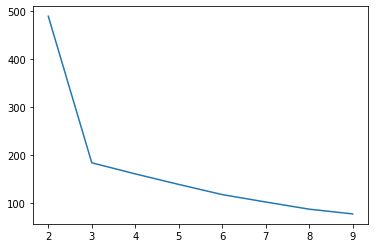

In [15]:
ks = []
ds = []
for k in range(2,10):
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(X)
    
    ks.append(k)
    ds.append(kmeans.inertia_)
plt.plot(ks,ds)
print(ks)
print(ds)

We plot the sum of square distance vs number of clusters. We will choose that number of cluster that brings maximum deviation in sum of square distance. This method is known as elbow method. The sum of square error goes on decreasing as number of cluster increases, but we choose that k that gives maximum deviation. It above graph k = 3 as there is maximum deviation when k=3.